# **Project 2**, APS1070 Fall 2022
**Anomaly Detection Algorithm using Gaussian Mixture Model**

**Deadline: Oct 27, 9 PM - 13 points**

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Name: Sudarsanamurthy Tenneti Prabakaramurthy
*   Student Number: 1008628601

### How to submit **(HTML + IPYNB)**

1. Download your notebook: `File -> Download .ipynb`

2. Click on the Files icon on the far left menu of Colab

3. Select & upload your `.ipynb` file you just downloaded, and then obtain its path (right click) (you might need to hit the Refresh button before your file shows up)


4. execute the following in a Colab cell:
```
%%shell
jupyter nbconvert --to html /PATH/TO/YOUR/NOTEBOOKFILE.ipynb
```

5. An HTML version of your notebook will appear in the files, so you can download it.

6. Submit **both** <font color='red'>`HTML` and `IPYNB`</font>  files on Quercus for grading.



Ref: https://stackoverflow.com/a/64487858 



##**Part 1: Getting started [2 Marks]**

We are going to work with a credit card fraud dataset. This dataset contains 28 key features, which are not 
directly interpretable but contain meaningful information about the dataset.

Load the dataset in CSV file using Pandas. The dataset is called `creditcard.csv`. Print out the first few columns of the dataset.

* How many rows are there? **284,807** **[0.1]**
* What features in the dataset are present aside from the 28 main features?  **Time, Amount, Class** **[0.1]**
* Which column contains the targets? **Class** **[0.1]**
* What is the meaning of target values? **The class column contains the target values where class 0 or the value 0 stands for valid transaction or valid data whereas the class 1 or the value 1 stands for fraudulent transaction or fraudulent data.**  **[0.1]**

In [ ]:
pip install wget

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import wget

wget.download('https://github.com/aps1070-2019/datasets/raw/master/creditcard.tar.gz','creditcard.tar.gz')

'creditcard.tar (1).gz'

In [ ]:
!tar -zxvf creditcard.tar.gz

creditcard.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
df = pd.read_csv('creditcard.csv')

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
class_0= sum(df['Class']==0)
class_1= sum(df['Class']==1)
total= len(df['Class'])
print(class_0,class_1)
print((class_0/total)*100, (class_1/total)*100)

284315 492
99.82725143693798 0.1727485630620034


It's important to know how many examples we have for each class when we work with a new dataset.

* What is the percentage of entries in the dataset for each class? **Class 0- 284315 entries- 99.827% of the data, Class 1- 492 entries- 0.173% of the data**  **[0.1]**
* Is this data considered balanced or unbalanced? Why is this the case? **Data is considered to be unbalanced as there is a very high difference between the number of entries we have for each class in the above dataset.** **[0.1]**
* Why is balance/imbalance important? How might this class ditribution affect a KNN classifier for example, which we explored in Project 1? _____ **[0.5]** **Making sure to know initially if the data is balanced or imbalanced is important as it conveys us about the metrics that we need to consider for evaluating the model. Balance of data is important as it makes sure that no certain class is given higher priority over the other and thereby generalizing the model and producing higher accuracy. KNN is affected by imbalanced datasets as it treats all neighbors of the instance equally and since our data is imbalanced, most of the neighbors will be of the majority class and thus we will not be able to differentiate minor class adequately.**
* What metrics should we use to evaluate a model in such cases _________ **[0.2]** **We make use of the Confusion matrix, Precision, Recall, Accuracy, Fallout and F1 score for such models.**


Next, split the dataset into a training (65%), validation (20%) and testing set (15%). Set the random state to 40. **[0.2]**

Make sure to separate out the column corresponding to the targets.

In [ ]:
### Split the data  ###

X_train_val, X_test, y_train_val, y_test= train_test_split(df.iloc[:, 1:-2], df.iloc[:,-1], test_size= 0.15, random_state= 40)
X_train, X_val, y_train, y_val= train_test_split(X_train_val, y_train_val, test_size= 0.2353, random_state= 40)


Now, let's take a look at the difference in distribution for some variables between fraudulent and non-fraudulent transactions:

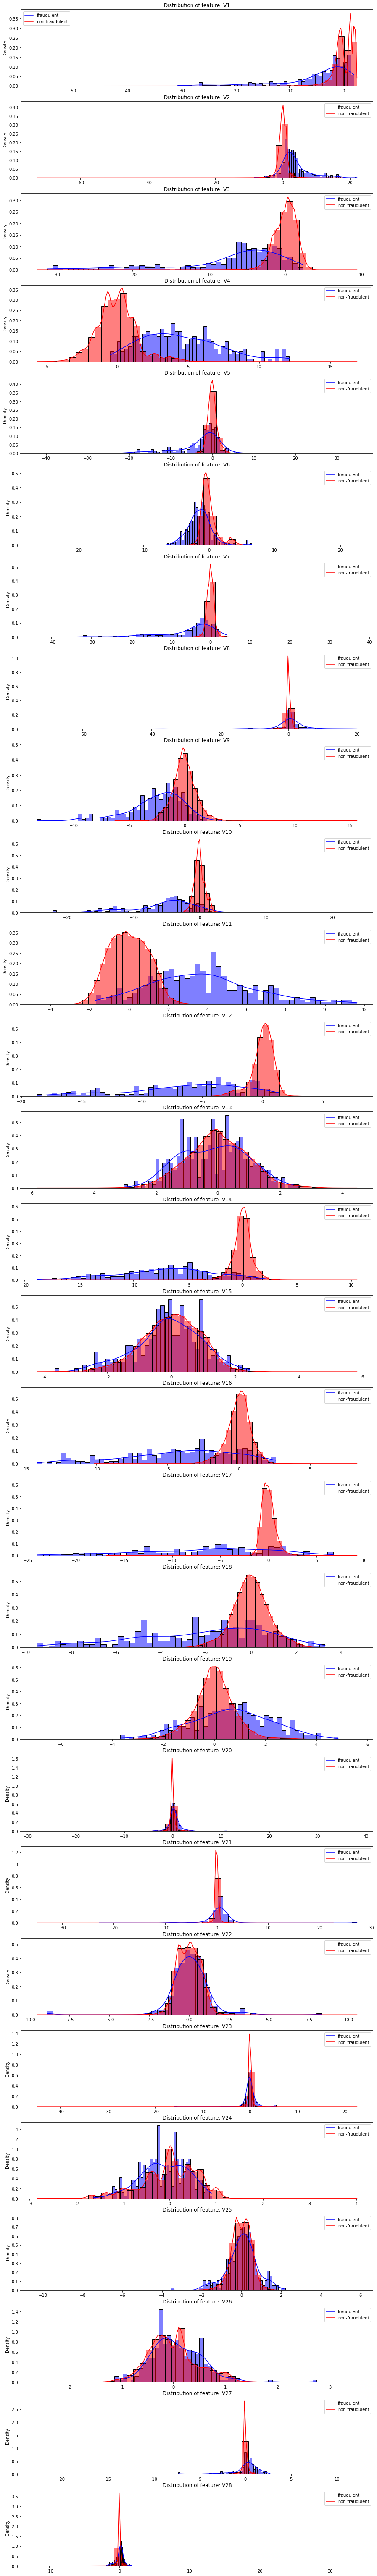

In [ ]:
import matplotlib.gridspec as gridspec
features=[f for f in df.columns if 'V' in f]
nplots=np.size(features)
plt.figure(figsize=(15,4*nplots))
gs = gridspec.GridSpec(nplots,1)
for i, feat in enumerate(features):
    ax = plt.subplot(gs[i])
    sns.histplot(X_train[feat][y_train==1], stat="density", kde=True, color="blue", bins=50)
    sns.histplot(X_train[feat][y_train==0], stat="density", kde=True, color="red", bins=50)
    ax.legend(['fraudulent', 'non-fraudulent'],loc='best')
    ax.set_xlabel('')
    ax.set_title('Distribution of feature: ' + feat)

Explain how these graphs could provide meaningful information about anomaly detection using a gaussian model. **[0.5]**

**The above graphs represent how many gaussian mixtures(number) are plotted on each feature and also showcases other important mathematical stats like the variance and mean of the gaussian model. From the graph, we can also identify which of the features are important for anomaly detection depending on the Gaussian model. The greater the variance of Gaussian on Fraudulent data, the more important the feature is for anomaly detection.**

## **Part 2: One Gaussian model with Single feature: [2 Marks]**
We'll start by making a prediction using **a single feature of our dataset at a time**. 

Please note that we **only use `V` features** in our model.

**a. Fitting regardless of class:**
  1. Fit a single Gaussian distribution on a single feature of **the full training dataset** (both classes) using ``sklearn.mixture.GaussianMixture`` when ``n_components=1``. 
  2. Compute AUC (Area under the ROC Curve) based on ``sklearn.mixture.GaussianMixture.score_samples`` on both the full training set and validation set (including both classes).  
  3. Repeat the above steps for each of the features and present your findings in a table. **[0.3]**
  4. Find the best 3 features to distinguish fraudulent transactions from non-fraudulent transactions based on the AUC of the validation set. **[0.2]**
  5. Make a prediction based on a model's scores: If the `score_samples` is lower than a threshold, we consider that transaction as a fraud. Find an optimal threshold that maximizes the F1 Score of the validation set for each of those 3 features separately. (Do not check every possible value for threshold, come up with a faster way!) Compute F1 score using `sklearn.metrics.f1_score`. **[0.5]**
  7. Report Precision, Recall and F1 score on both training and validation set in a table using the threshold you found in previous step. 
  6. Report the complexity of your method (Big O notation) for determining the optimal threshold.**[0.3]** 

For the function that I have written, the algorithm running time is as follows: The loop initially runs (n/100) times based on the value of p and then inside the loop, the p < threshold value runs n1 times. After that, the next disjoint loops runs 50 times each. Thus totally, the Big O is given by after neglecting the constant values O(n*(n1)). 

**b. Fitting based on class:**
 1. Pick 3 features that had the best AUC in Part 2a. 
 2. repeat part 2a to compute AUC, F1 score, Precision and Recall when you fit a Gaussian **only on non-fraudulent transactions in the training set** in step 1 (instead of all the transactions).
 3. Compare your results from parts 2a and 2b in a table (for both training and validation set). **[0.2]**
 4. Are these results different or similar? Why?**[0.5]** **The results are almost similar for F1 scores, Precision scores and Recall scores. This is because our dataset is an imbalanced one with 99.8% of data as non-fraudulent and only about 0.2% of it is fraudulent. Thus, we are fitting almost similar data and that is why we are getting similar results.**


In [ ]:
### YOUR CODE HERE ###
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from tabulate import tabulate

features=[f for f in df.columns if 'V' in f]
auc_train=[]
auc_val=[]
for i, feat in enumerate(features):
  X_train_sf= X_train.iloc[:,i].values.reshape(-1,1)
  X_val_sf= X_val.iloc[:,i].values.reshape(-1,1)
  
  gm_sf = GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)
  gm_sf.fit(X_train_sf)
  
  p_train = gm_sf.score_samples(X_train_sf)
  p_val = gm_sf.score_samples(X_val_sf)
  
  fpr_sf_train, tpr_sf_train, _ = roc_curve(y_train, -1 * p_train)  
  fpr_sf_val, tpr_sf_val, _  = roc_curve(y_val, -1 * p_val)

  auc_train= np.append(auc_train, auc(fpr_sf_train, tpr_sf_train))
  auc_val= np.append(auc_val, auc(fpr_sf_val, tpr_sf_val))

tabulated_data_train= [[x for x in auc_train]]
print("The AUC score for training dataset is:\n")
print(tabulate(tabulated_data_train, headers= features, tablefmt= 'fancy_grid'))
tabulated_data_val= [[x for x in auc_val]]
print("\nThe AUC score for validation dataset is:\n")
print(tabulate(tabulated_data_val, headers= features, tablefmt= 'fancy_grid'))

auc_val_desc_sorted= sorted(auc_val, reverse=True)[:3]
auc_val_best3f_index= np.where(np.isin(auc_val, auc_val_desc_sorted)== True)
print("\n\nThe best 3 features to distinguish fraudulent transactions from non-fraudulent transactions based on the AUC of the validation set are:", auc_val_best3f_index[0]+1)


The AUC score for training dataset is:

╒══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╤══════════╕
│       V1 │       V2 │       V3 │       V4 │       V5 │       V6 │       V7 │       V8 │       V9 │      V10 │      V11 │      V12 │      V13 │      V14 │      V15 │      V16 │      V17 │      V18 │      V19 │      V20 │      V21 │      V22 │      V23 │      V24 │      V25 │      V26 │      V27 │      V28 │
╞══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ 0.692541 │ 0.848244 │ 0.8700

In [ ]:
from sklearn.metrics import f1_score

gm_bf1= GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)
gm_bf2= GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)
gm_bf3= GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)

gm_bf1.fit(X_train.iloc[:,9].values.reshape(-1,1))
gm_bf2.fit(X_train.iloc[:,13].values.reshape(-1,1))
gm_bf3.fit(X_train.iloc[:,16].values.reshape(-1,1))

p_bf1_val= gm_bf1.score_samples(X_val.iloc[:,9].values.reshape(-1,1))
p_bf2_val= gm_bf2.score_samples(X_val.iloc[:,13].values.reshape(-1,1))
p_bf3_val= gm_bf3.score_samples(X_val.iloc[:,16].values.reshape(-1,1))

def optimum_threshold(p,y):
  l= len(p)
  temp= [x for x in range(0,l,100)]
  f1_scores=[]
  temp_i=[]
  f1_scores_final=[]
  final_i=[]

  for i in temp:
    threshold_temp= sorted(p)[i]
    scores_temp1= f1_score(y, p<threshold_temp)
    f1_scores= np.append(f1_scores,scores_temp1)
    temp_i=np.append(temp_i,i)

  max_score_index= np.argmax(f1_scores)
  corresp_i= temp_i[max_score_index]

  for i in range(int(corresp_i-50),int(corresp_i),1):
    threshold= sorted(p)[i]
    scores_temp2= f1_score(y, p<threshold)
    f1_scores_final= np.append(f1_scores_final,scores_temp2)
    final_i= np.append(final_i,i)

  for i in range(int(corresp_i),int(corresp_i+50),1):
    threshold= sorted(p)[i]
    scores_temp2= f1_score(y, p<threshold)
    f1_scores_final= np.append(f1_scores_final,scores_temp2)
    final_i= np.append(final_i,i)

  return f1_scores_final.max(),sorted(p)[int(final_i[int(np.argmax(f1_scores_final))])]
 

In [ ]:
f1_score_bf1, threshold_bf1= optimum_threshold(p_bf1_val,y_val)
print(f1_score_bf1, threshold_bf1)
f1_score_bf2, threshold_bf2= optimum_threshold(p_bf2_val,y_val)
print(f1_score_bf2, threshold_bf2)
f1_score_bf3, threshold_bf3= optimum_threshold(p_bf3_val,y_val)
print(f1_score_bf3, threshold_bf3)

0.21120689655172412 -10.479147407976091
0.6192893401015229 -19.241617828267305
0.5977011494252873 -22.02630577170168


In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

p_bf1_train= gm_bf1.score_samples(X_train.iloc[:,9].values.reshape(-1,1))
p_bf2_train= gm_bf2.score_samples(X_train.iloc[:,13].values.reshape(-1,1))
p_bf3_train= gm_bf3.score_samples(X_train.iloc[:,16].values.reshape(-1,1))

precision_bf1_train = precision_score(y_train, p_bf1_train < threshold_bf1)
recall_bf1_train = recall_score(y_train, p_bf1_train < threshold_bf1)
f1_score_bf1_train = (2* precision_bf1_train* recall_bf1_train)/(precision_bf1_train+ recall_bf1_train)

precision_bf2_train = precision_score(y_train, p_bf2_train < threshold_bf2)
recall_bf2_train = recall_score(y_train, p_bf2_train < threshold_bf2)
f1_score_bf2_train = (2* precision_bf2_train* recall_bf2_train)/(precision_bf2_train+ recall_bf2_train)

precision_bf3_train = precision_score(y_train, p_bf3_train < threshold_bf3)
recall_bf3_train = recall_score(y_train, p_bf3_train < threshold_bf3)
f1_score_bf3_train = (2* precision_bf3_train* recall_bf3_train)/(precision_bf3_train+ recall_bf3_train)

precision_bf1_val = precision_score(y_val, p_bf1_val < threshold_bf1)
recall_bf1_val = recall_score(y_val, p_bf1_val < threshold_bf1)

precision_bf2_val = precision_score(y_val, p_bf2_val < threshold_bf2)
recall_bf2_val = recall_score(y_val, p_bf2_val < threshold_bf2)

precision_bf3_val = precision_score(y_val, p_bf3_val < threshold_bf3)
recall_bf3_val = recall_score(y_val, p_bf3_val < threshold_bf3)

precision_scores_train= [precision_bf1_train, precision_bf2_train, precision_bf3_train]
recall_scores_train= [recall_bf1_train, recall_bf2_train, recall_bf3_train]
f1_scores_train= [f1_score_bf1_train, f1_score_bf2_train, f1_score_bf3_train]

precision_scores_val= [precision_bf1_val, precision_bf2_val, precision_bf3_val]
recall_scores_val= [recall_bf1_val, recall_bf2_val, recall_bf3_val]
f1_scores_val= [f1_score_bf1, f1_score_bf2, f1_score_bf3]

print(tabulate([[precision_scores_train]], headers=['Precision of Training data of 3 best features'], tablefmt='fancy_grid'))
print(tabulate([[recall_scores_train]], headers=['Recall of Training data of 3 best features'], tablefmt='fancy_grid'))
print(tabulate([[f1_scores_train]], headers=['F1 score of Training data of 3 best features'], tablefmt='fancy_grid'))
print(tabulate([[precision_scores_val]], headers=['Precision of Validation data of 3 best features'], tablefmt='fancy_grid'))
print(tabulate([[recall_scores_val]], headers=['Recall of Validation data of 3 best features'], tablefmt='fancy_grid'))
print(tabulate([[f1_scores_val]], headers=['F1 score of Validation data of 3 best features'], tablefmt='fancy_grid'))

╒══════════════════════════════════════════════════════════════╕
│ Precision of Training data of 3 best features                │
╞══════════════════════════════════════════════════════════════╡
│ [0.11572226656025539, 0.622895622895623, 0.6530612244897959] │
╘══════════════════════════════════════════════════════════════╛
╒══════════════════════════════════════════════════════════════╕
│ Recall of Training data of 3 best features                   │
╞══════════════════════════════════════════════════════════════╡
│ [0.4503105590062112, 0.5745341614906833, 0.4968944099378882] │
╘══════════════════════════════════════════════════════════════╛
╒══════════════════════════════════════════════════════════════╕
│ F1 score of Training data of 3 best features                 │
╞══════════════════════════════════════════════════════════════╡
│ [0.18412698412698414, 0.5977382875605816, 0.564373897707231] │
╘══════════════════════════════════════════════════════════════╛
╒════════════════════════

In [ ]:
index_fraud_train= np.where(y_train==1)
index_fraud_train= list(index_fraud_train[0])

X_train_non_fraud= np.delete(X_train.values, index_fraud_train, axis=0)

auc_train_nf=[]
auc_val_nf=[]

gm_sf_nf = GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)

for i in [9,13,16]:

  X_train_non_fraud_sf= X_train_non_fraud[:,i].reshape(-1,1)
 
  gm_sf_nf.fit(X_train_non_fraud_sf)
 
  p_train_non_fraud = gm_sf_nf.score_samples(X_train.iloc[:,i].values.reshape(-1,1))
  p_val_non_fraud = gm_sf_nf.score_samples(X_val.iloc[:,i].values.reshape(-1,1))
  
  fpr_sf_nf_train, tpr_sf_nf_train, _ = roc_curve(y_train, -1 * p_train_non_fraud)  
  fpr_sf_nf_val, tpr_sf_nf_val, _  = roc_curve(y_val, -1 * p_val_non_fraud)

  auc_train_nf= np.append(auc_train_nf, auc(fpr_sf_nf_train, tpr_sf_nf_train))
  auc_val_nf= np.append(auc_val_nf, auc(fpr_sf_nf_val, tpr_sf_nf_val))

auc_train_fd= [auc_train[9],auc_train[13],auc_train[16]]
auc_val_fd= [auc_val[9],auc_val[13],auc_val[16]]

tabulated_auc_train = [[auc_train_fd,auc_train_nf]]
print(tabulate(tabulated_auc_train, headers=['AUC of Training data Full dataset','AUC of Training data Non Fraudulent dataset'], tablefmt='grid'))

tabulated_auc_val = [[auc_val_fd,auc_val_nf]]
print(tabulate(tabulated_auc_val, headers=['AUC of Validation data Full dataset','AUC of Validation data Non Fraudulent dataset'], tablefmt='grid'))

+--------------------------------------------------------------+-----------------------------------------------+
| AUC of Training data Full dataset                            | AUC of Training data Non Fraudulent dataset   |
+==============================================================+===============================================+
| [0.9100252581269662, 0.9480139852383641, 0.9289363017934447] | [0.91016918 0.9483173  0.9283978 ]            |
+--------------------------------------------------------------+-----------------------------------------------+
+-------------------------------------------------------------+-------------------------------------------------+
| AUC of Validation data Full dataset                         | AUC of Validation data Non Fraudulent dataset   |
+=============================================================+=================================================+
| [0.9172793578837419, 0.9550656899470364, 0.925698409364977] | [0.91726712 0.95491551 0.9252

In [ ]:
gm_nf_bf1= GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)
gm_nf_bf2= GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)
gm_nf_bf3= GaussianMixture(n_components = 1, covariance_type = 'full', random_state= 40)

gm_nf_bf1.fit(X_train_non_fraud[:,9].reshape(-1,1))
gm_nf_bf2.fit(X_train_non_fraud[:,13].reshape(-1,1))
gm_nf_bf3.fit(X_train_non_fraud[:,16].reshape(-1,1))

p_nf_bf1_val= gm_nf_bf1.score_samples(X_val.iloc[:,9].values.reshape(-1,1))
p_nf_bf2_val= gm_nf_bf2.score_samples(X_val.iloc[:,13].values.reshape(-1,1))
p_nf_bf3_val= gm_nf_bf3.score_samples(X_val.iloc[:,16].values.reshape(-1,1))

f1_score_nf_bf1, threshold_nf_bf1= optimum_threshold(p_nf_bf1_val,y_val)
print(f1_score_nf_bf1, threshold_nf_bf1)
f1_score_nf_bf2, threshold_nf_bf2= optimum_threshold(p_nf_bf2_val,y_val)
print(f1_score_nf_bf2, threshold_nf_bf2)
f1_score_nf_bf3, threshold_nf_bf3= optimum_threshold(p_nf_bf3_val,y_val)
print(f1_score_nf_bf3, threshold_nf_bf3)

0.2121212121212121 -11.3158670860163
0.6192893401015229 -21.84743598863287
0.5977011494252873 -27.53997713218924


In [ ]:
p_nf_bf1_train= gm_nf_bf1.score_samples(X_train.iloc[:,9].values.reshape(-1,1))
p_nf_bf2_train= gm_nf_bf2.score_samples(X_train.iloc[:,13].values.reshape(-1,1))
p_nf_bf3_train= gm_nf_bf3.score_samples(X_train.iloc[:,16].values.reshape(-1,1))

precision_nf_bf1_train = precision_score(y_train, p_nf_bf1_train < threshold_nf_bf1)
recall_nf_bf1_train = recall_score(y_train, p_nf_bf1_train < threshold_nf_bf1)
f1_score_nf_bf1_train = (2* precision_nf_bf1_train* recall_nf_bf1_train)/(precision_nf_bf1_train+ recall_nf_bf1_train)

precision_nf_bf2_train = precision_score(y_train, p_nf_bf2_train < threshold_nf_bf2)
recall_nf_bf2_train = recall_score(y_train, p_nf_bf2_train < threshold_nf_bf2)
f1_score_nf_bf2_train = (2* precision_nf_bf2_train* recall_nf_bf2_train)/(precision_nf_bf2_train+ recall_nf_bf2_train)

precision_nf_bf3_train = precision_score(y_train, p_nf_bf3_train < threshold_nf_bf3)
recall_nf_bf3_train = recall_score(y_train, p_nf_bf3_train < threshold_nf_bf3)
f1_score_nf_bf3_train = (2* precision_nf_bf3_train* recall_nf_bf3_train)/(precision_nf_bf3_train+ recall_nf_bf3_train)

precision_nf_bf1_val = precision_score(y_val, p_nf_bf1_val < threshold_nf_bf1)
recall_nf_bf1_val = recall_score(y_val, p_nf_bf1_val < threshold_nf_bf1)

precision_nf_bf2_val = precision_score(y_val, p_nf_bf2_val < threshold_nf_bf2)
recall_nf_bf2_val = recall_score(y_val, p_nf_bf2_val < threshold_nf_bf2)

precision_nf_bf3_val = precision_score(y_val, p_nf_bf3_val < threshold_nf_bf3)
recall_nf_bf3_val = recall_score(y_val, p_nf_bf3_val < threshold_nf_bf3)

precision_scores_train_nf= [precision_nf_bf1_train, precision_nf_bf2_train, precision_nf_bf3_train]
recall_scores_train_nf= [recall_nf_bf1_train, recall_nf_bf2_train, recall_nf_bf3_train]
f1_scores_train_nf= [f1_score_nf_bf1_train, f1_score_nf_bf2_train, f1_score_nf_bf3_train]

precision_scores_val_nf= [precision_nf_bf1_val, precision_nf_bf2_val, precision_nf_bf3_val]
recall_scores_val_nf= [recall_nf_bf1_val, recall_nf_bf2_val, recall_nf_bf3_val]
f1_scores_val_nf= [f1_score_nf_bf1, f1_score_nf_bf2, f1_score_nf_bf3]

tabulated_precision_train = [[precision_scores_train, precision_scores_train_nf]]
tabulated_precision_val = [[precision_scores_val, precision_scores_val_nf]]
tabulated_recall_train = [[recall_scores_train, recall_scores_train_nf]]
tabulated_recall_val = [[recall_scores_val, recall_scores_val_nf]]
tabulated_f1_score_train = [[f1_scores_train, f1_scores_train_nf]]
tabulated_f1_score_val = [[f1_scores_val, f1_scores_val_nf]]

print(tabulate(tabulated_precision_train, headers=['Precision of Training data Full dataset','Precision of Training data Non Fraudulent dataset'], tablefmt='grid'))
print(tabulate(tabulated_precision_val, headers=['Precision of Validation data Full dataset','Precision of Validation data Non Fraudulent dataset'], tablefmt='grid'))
print(tabulate(tabulated_recall_train, headers=['Recall of Training data Full dataset','Recall of Training data Non Fraudulent dataset'], tablefmt='grid'))
print(tabulate(tabulated_recall_val, headers=['Recall of Validation data Full dataset','Recall of Validation data Non Fraudulent dataset'], tablefmt='grid'))
print(tabulate(tabulated_f1_score_train, headers=['F1 score of Training data Full dataset','F1 score of Training data Non Fraudulent dataset'], tablefmt='grid'))
print(tabulate(tabulated_f1_score_val, headers=['F1 score of Validation data Full dataset','F1 score of Validation data Non Fraudulent dataset'], tablefmt='grid'))



+--------------------------------------------------------------+--------------------------------------------------------------+
| Precision of Training data Full dataset                      | Precision of Training data Non Fraudulent dataset            |
+==============================================================+==============================================================+
| [0.11572226656025539, 0.622895622895623, 0.6530612244897959] | [0.11627906976744186, 0.622895622895623, 0.6530612244897959] |
+--------------------------------------------------------------+--------------------------------------------------------------+
+---------------------------------------------------------------+--------------------------------------------------------------+
| Precision of Validation data Full dataset                     | Precision of Validation data Non Fraudulent dataset          |
+===============================================================+=====================================

## **Part 3: One Gaussian model with multiple features: [2 Marks]**
This part is similar to Part 2, but here we will pick multiple features and set the number of components **visually**.

 1. Pick two features (say, f1 and f2). 
 2. Scatter plot (plt.scatter) those features of the training set on a figure (f1 on the x-axis and f2 on the y-axis). **[0.25]**
 3. On the scatter plot color the training set based on their class (non-fraudulents blue and fraudulents red). **[0.25]**
 4. Based on your plots decide how many Gaussian components (``n_components``) you need to fit the data (focus on valid transactions). **[0.25]** **Based on the above graph, focusing on the valid transactions, we can see that there are about 3 groups and thus, I am choosing the n_components = 3**
 5. Fit your Gaussian model on the training set (all samples). 
 6. Compute AUC on both training and validation sets **[0.25]**
 7. Pick 3 new pair of features and repeat steps 2 to 6. **[0.5]**
 8. Pick the set with the highest AUC on the validation set (out of the four sets that you tried.)
 9. Find a threshold to maximize your F1 Score on the validation set.**[0.25]**
 10. Plot two seperate figures (one for the training data and one for the validation data) similar to step 3 and put a circle around outliers based on your threshold (use the code of the similar figure in tutorial) **[0.25]**




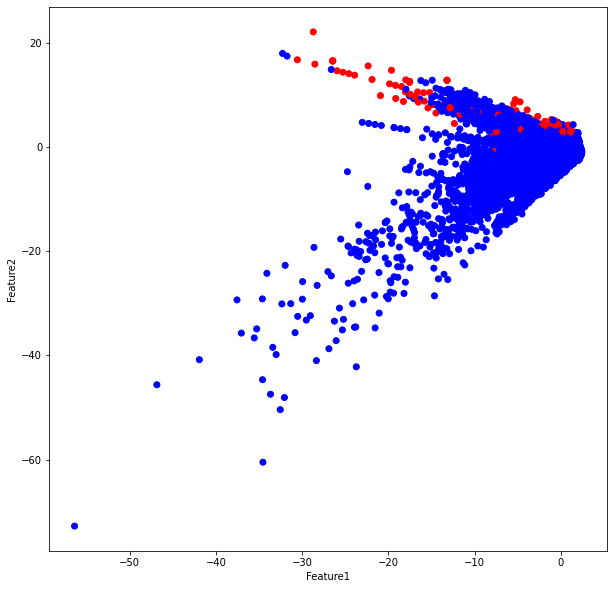

In [ ]:
### YOUR CODE HERE ###
plt.figure(figsize=(10,10))
plt.scatter(X_train.iloc[:,0],X_train.iloc[:,1], c= y_train.map({0:'b', 1:'r'}))
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

In [ ]:
### Based on the above graph, focusing on the valid transactions, we can see that there are about 3 groups and thus, I am choosing the
### n_components = 3

from sklearn.metrics import roc_auc_score

def plot_auc(i,j):

  plt.figure(figsize=(10,10))
  plt.scatter(X_train.iloc[:,i-1],X_train.iloc[:,j-1], c= y_train.map({0:'b', 1:'r'}))
  feature1_name= 'feature'+ ' '+ str(i)
  feature2_name= 'feature'+ ' '+ str(j)
  plt.xlabel(feature1_name)
  plt.ylabel(feature2_name)
  plt.show()

  gmm2f= GaussianMixture(n_components= 3, covariance_type= 'full', random_state= 40)
  gmm2f.fit(X_train.iloc[:,[i-1,j-1]].values)

  X_train_2f= X_train.iloc[:,[i-1,j-1]].values
  X_val_2f= X_val.iloc[:,[i-1,j-1]].values

  p_train_2f= gmm2f.score_samples(X_train_2f)
  p_val_2f= gmm2f.score_samples(X_val_2f)

  auc_train_2f = roc_auc_score(y_train, -1* p_train_2f)
  auc_val_2f = roc_auc_score(y_val, -1* p_val_2f)
 
  return auc_train_2f, auc_val_2f, p_val_2f, p_train_2f



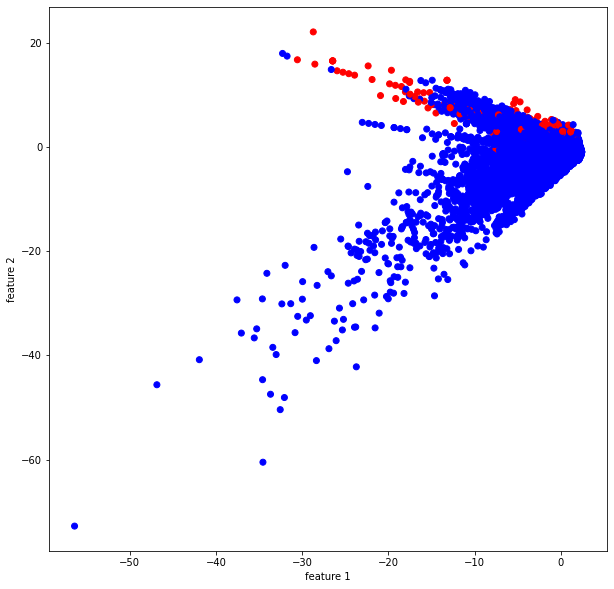

The AUC score on training set for features 1 and 2 is: 0.8839865323599796
The AUC score on validation set for features 1 and 2 is: 0.8842842073429149


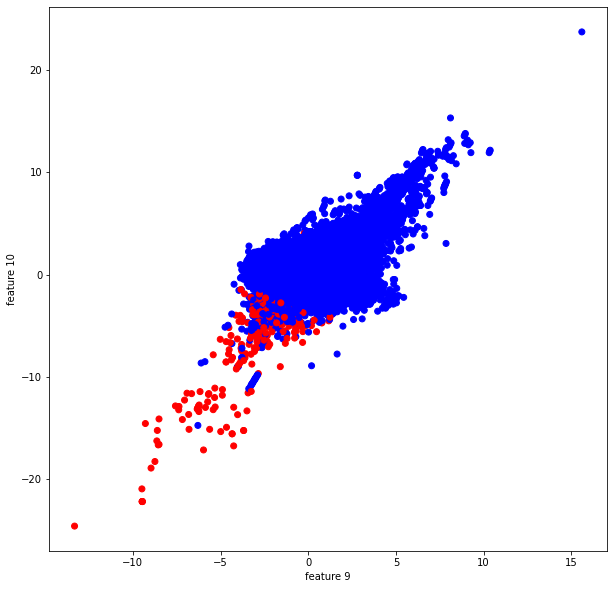

The AUC score on training set for features 9 and 10 is: 0.9145253387916431
The AUC score on validation set for features 9 and 10 is: 0.927707264119485


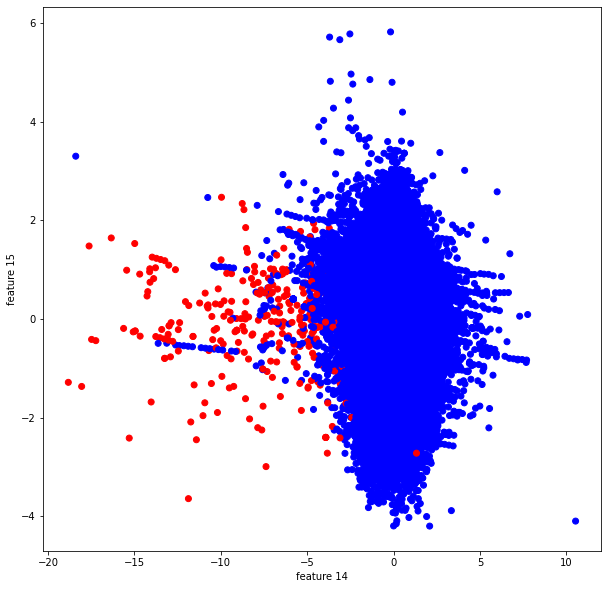

The AUC score on training set for features 14 and 15 is: 0.9552376751095695
The AUC score on validation set for features 14 and 15 is: 0.9561793448143752


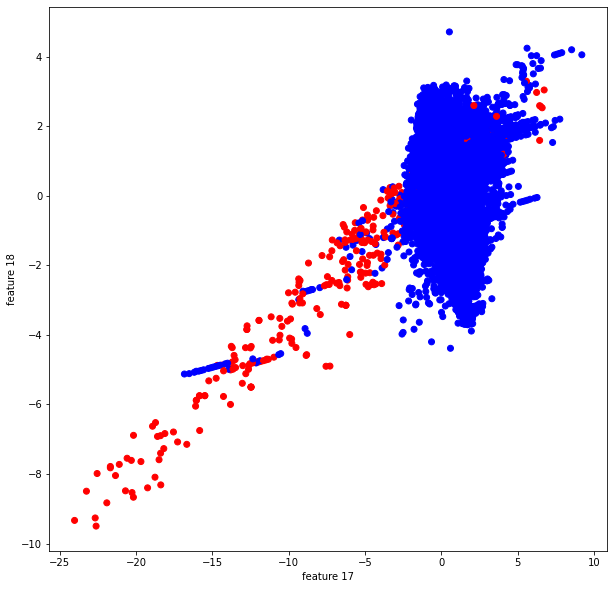

The AUC score on training set for features 17 and 18 is: 0.9377365491651206
The AUC score on validation set for features 17 and 18 is: 0.9261316985245409


In [ ]:
auc1,auc2,p1_2f_val,p1_2f_train= plot_auc(1,2)
print("The AUC score on training set for features 1 and 2 is:",auc1)
print("The AUC score on validation set for features 1 and 2 is:",auc2)
auc9,auc10,p2_2f_val,p2_2f_train= plot_auc(9,10)
print("The AUC score on training set for features 9 and 10 is:",auc9)
print("The AUC score on validation set for features 9 and 10 is:",auc10)
auc14,auc15,p3_2f_val,p3_2f_train= plot_auc(14,15)
print("The AUC score on training set for features 14 and 15 is:",auc14)
print("The AUC score on validation set for features 14 and 15 is:",auc15)
auc17,auc18,p4_2f_val,p4_2f_train= plot_auc(17,18)
print("The AUC score on training set for features 17 and 18 is:",auc17)
print("The AUC score on validation set for features 17 and 18 is:",auc18)

In [ ]:
# From the above plots and results we can see that the pair Feature 14, Feature 15 has the best AUC score on validation set
# Thus, I am going to find the optimum threshold for this feature pair which maximizes its F1 score on the validation set

f1_scores_2f_val, threshold_2f_val= optimum_threshold(p3_2f_val, y_val)
print('The Maximum F1 score for Validation set is:',f1_scores_2f_val,'and its corresponding optimum threshold is:', threshold_2f_val)

f1_scores_2f_train, threshold_2f_train= optimum_threshold(p3_2f_train, y_train)
print('The Maximum F1 score for Training set is:',f1_scores_2f_train,'and its corresponding optimum threshold is:', threshold_2f_train)

The Maximum F1 score for Validation set is: 0.5473684210526317 and its corresponding optimum threshold is: -11.111706201554103
The Maximum F1 score for Training set is: 0.5197368421052632 and its corresponding optimum threshold is: -10.594158641387695


Plot between Feature 14 and Feature 15 on Validation data


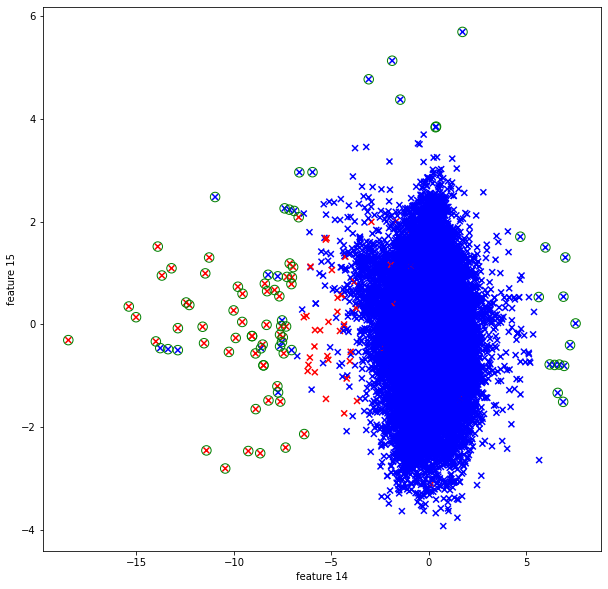

In [ ]:
#Plotting 2 plots for training data and validation data separately for the above selected Feature pair of Feature 14 and Feature 15
#and marking the outliers based on the threshold calculated above

print("Plot between Feature 14 and Feature 15 on Validation data")
plt.figure(figsize=(10,10))
plt.scatter(X_val.iloc[:,13], X_val.iloc[:,14], marker='x', c= y_val.map({0:'blue', 1:'red'}))
outliers = np.nonzero(p3_2f_val < threshold_2f_val)[0]
plt.scatter(X_val.iloc[outliers,13],X_val.iloc[outliers,14],marker="o",facecolor= "none",edgecolor="g",s=90)
plt.xlabel('feature 14')
plt.ylabel('feature 15')
plt.show()

Plot between Feature 14 and Feature 15 on Training data


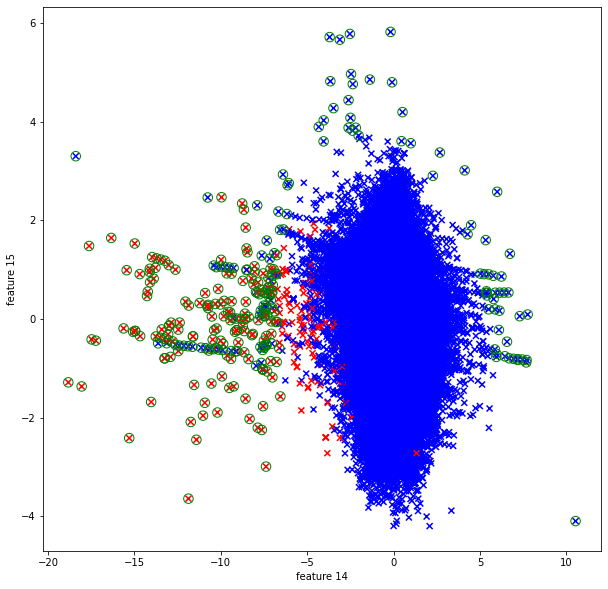

In [ ]:
print("Plot between Feature 14 and Feature 15 on Training data")
plt.figure(figsize=(10,10))
plt.scatter(X_train.iloc[:,13], X_train.iloc[:,14], marker='x', c= y_train.map({0:'blue', 1:'red'}))
outliers = np.nonzero(p3_2f_train < threshold_2f_train)[0]
plt.scatter(X_train.iloc[outliers,13],X_train.iloc[outliers,14],marker="o",facecolor= "none",edgecolor="g",s=90)
plt.xlabel('feature 14')
plt.ylabel('feature 15')
plt.show()

## **Part 4:  Two Gaussian model with single feature. [3 Marks]**
Now we will use two separate distributions for fraudulent and non-fraudulent transactions.
  1.  Fit a Gaussian distribution ($G_1$) on a feature of **non-fraudulent transactions** using ``sklearn.mixture.GaussianMixture`` when ``n_components=1``. **[0.5]**
  2. Fit another Gaussian distribution ($G_2$) on the same feature but for **fraudulent transactions** using ``sklearn.mixture.GaussianMixture`` when ``n_components=1``. **[0.5]**
  3. Compute the score samples ($S$) for both $G_1$ and $G_2$ on the **validation set** to get $S_1$ and $S_2$, respectively. **[0.5]**
  4. Find an optimal $c$ (a real number) that maximizes validation set F1 Score for a model such that if $S_1 < c \times S_2$, the transaction is classified as a fraud. For example, if $c=1$ we could say that if $S_2$ is greater than $S_1$, ($S_1$<$S_2$) then the transaction is a fraud (the transaction belongs to the $G_2$ distribution which represents fraudulent transactions). For start consider $c$ in $[0,10]$ with steps of 0.1, you can change this window in your experiments if needed. **[0.5]**
  5. Repeat the steps above for all the features. What is the best F1 Score, Precision and Recall that you get for training and validation? Which feature and what c? Show your results in a table. **[0.5]**
  6. Can we report AUC for this model? Why? **[0.5]** **No, we cannot report AUC for this model. AUC is area under the ROC curve which is plotted against True positive rate Vs False positive rate. Since in this two GMM model, we are fitting the non-fraudulent and fraudulent data separately on 2 GMM's, we do not have true positives, false positives, true negatives and false negatives. Thus, ROC cannot be formed and subequently, the AUC cannot be calculated.**

In [100]:
#Code for one feature alone(V1 feature)

index_not_fraud_train= np.where(y_train==0)
index_not_fraud_train= list(index_not_fraud_train[0])

X_train_fraud= np.delete(X_train.values, index_not_fraud_train, axis=0)

gm1 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
gm1.fit(X_train_non_fraud[:,0].reshape(-1,1))

gm2 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
gm2.fit(X_train_fraud[:,0].reshape(-1,1))

s1_val= gm1.score_samples(X_val.iloc[:,0].values.reshape(-1,1))
s2_val= gm2.score_samples(X_val.iloc[:,0].values.reshape(-1,1))

C= np.arange(0, 10, 0.1)

final_scores=[]
temp_c=[]

for i in C:
  temp_scores= f1_score(y_val,s1_val < (i * s2_val))
  final_scores= np.append(final_scores, temp_scores)
  temp_c= np.append(temp_c,i)

print('The optimal C value for Feature V1 is:',temp_c[np.argmax(final_scores)],'and its F1 score is:',final_scores.max())


The optimal C value for Feature V1 is: 6.6000000000000005 and its F1 score is: 0.1523809523809524


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [104]:
#Code for all the features

final_scores=[]
temp_c=[]
corresp_c_val=[]
max_scores_val=[]
temp_f1_scores_train=[]
temp_prec_scores_train=[]
temp_rec_scores_train=[]
temp_prec_scores_val=[]
temp_rec_scores_val=[]

for i in range(0,len(X_train.iloc[0,:]),1):

  gm1 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
  gm1.fit(X_train_non_fraud[:,i].reshape(-1,1))

  gm2 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
  gm2.fit(X_train_fraud[:,i].reshape(-1,1))

  s1_val= gm1.score_samples(X_val.iloc[:,i].values.reshape(-1,1))
  s2_val= gm2.score_samples(X_val.iloc[:,i].values.reshape(-1,1))

  s1_train= gm1.score_samples(X_train.iloc[:,i].values.reshape(-1,1))
  s2_train= gm2.score_samples(X_train.iloc[:,i].values.reshape(-1,1))

  C= np.arange(0, 10, 0.1)

  for j in C:
    
    temp_scores= f1_score(y_val, s1_val < (j * s2_val))
    final_scores= np.append(final_scores, temp_scores)
    temp_c= np.append(temp_c,j)
  
  max_scores_val= np.append(max_scores_val, final_scores.max())
  corresp_c_val= np.append(corresp_c_val,temp_c[np.argmax(final_scores)])

  f1_score_train= f1_score(y_train, s1_train < (corresp_c_val[i] * s2_train))
  temp_f1_scores_train= np.append(temp_f1_scores_train, f1_score_train)

  prec_score_train= precision_score(y_train, s1_train < (corresp_c_val[i] * s2_train))
  temp_prec_scores_train= np.append(temp_prec_scores_train, prec_score_train)

  rec_score_train= recall_score(y_train, s1_train < (corresp_c_val[i] * s2_train))
  temp_rec_scores_train= np.append(temp_rec_scores_train, rec_score_train)

  prec_score_val= precision_score(y_val, s1_val < (corresp_c_val[i] * s2_val))
  temp_prec_scores_val= np.append(temp_prec_scores_val, prec_score_val)

  rec_score_val= recall_score(y_val, s1_val < (corresp_c_val[i] * s2_val))
  temp_rec_scores_val= np.append(temp_rec_scores_val, rec_score_val)

max_f1_score_val= np.max(max_scores_val)
optimal_c_val= corresp_c_val[np.argmax(max_scores_val)]
max_prec_val= temp_prec_scores_val[np.argmax(max_scores_val)]
max_rec_val= temp_rec_scores_val[np.argmax(max_scores_val)]

max_f1_score_train= np.max(temp_f1_scores_train)
max_prec_train= temp_prec_scores_train[np.argmax(temp_f1_scores_train)]
max_rec_train= temp_rec_scores_train[np.argmax(temp_f1_scores_train)]

print(tabulate([[max_f1_score_val, max_prec_val,max_rec_val,optimal_c_val, np.argmax(max_scores_val)+1]],
                  headers=['Max F1 score on Validation Data','Corresponding Precision Score','Corresponding Recall Score',
                           'Corresponding Optimal C value','Best Feature'],tablefmt='fancy_grid'))

print(tabulate([[max_f1_score_train, max_prec_train,max_rec_train,optimal_c_val, np.argmax(temp_f1_scores_train)+1]],
                  headers=['Max F1 score on Training Data','Corresponding Precision Score','Corresponding Recall Score',
                           'Corresponding Optimal C value','Best Feature'],tablefmt='fancy_grid'))


╒═══════════════════════════════════╤═════════════════════════════════╤══════════════════════════════╤═════════════════════════════════╤════════════════╕
│   Max F1 score on Validation Data │   Corresponding Precision Score │   Corresponding Recall Score │   Corresponding Optimal C value │   Best Feature │
╞═══════════════════════════════════╪═════════════════════════════════╪══════════════════════════════╪═════════════════════════════════╪════════════════╡
│                          0.670157 │                        0.719101 │                     0.627451 │                             5.9 │             17 │
╘═══════════════════════════════════╧═════════════════════════════════╧══════════════════════════════╧═════════════════════════════════╧════════════════╛
╒═════════════════════════════════╤═════════════════════════════════╤══════════════════════════════╤═════════════════════════════════╤════════════════╕
│   Max F1 score on Training Data │   Corresponding Precision Score │   Corres

## **Part 5: Multivariate and Mixture of Gaussians Distribution [3 Marks]**
We now want to build an outlier detection model that performs well in terms of F1 score. To design your model, you can benefit from:

*   No restrictions on the number of features - use as few or as many as you want! (multivariate). 
*   To fit your model, you can take advantage of the Gaussian mixture model where you can set the number of components [help](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html) .
*   You can choose to fit your Gaussians on non-fraudulent transactions or to both classes. 


It is up to you how to design your model. Try at least 10 different models and report the AUC for both training and validation sets (if applicable) and the best F1 score, Precision and Recall (after tuning the threshold) for both training and validation sets for each model. What kind of model works better? How many features are best (and which ones)? How many Gaussians? How many components? Summarize your findings with tables or plots. **[3]**


**HINT !**

You might want to try a two gaussian model, multiple features, single component for valid transaction and multiple components for fraudulent ones! Why does it make sense to have multiple components for the fraudulent transactions?

In [ ]:
### Model 1: One Gaussian Mixture One Feature Two Components Fit on Both Classes

gm_m1=GaussianMixture(n_components=2, covariance_type= 'full', random_state= 40)
gm_m1.fit(X_train.iloc[:,13].values.reshape(-1,1)) # Choosing Feature 14 as it had the highest AUC score in Part 2

p_train_m1= gm_m1.score_samples(X_train.iloc[:,13].values.reshape(-1,1))
p_val_m1= gm_m1.score_samples(X_val.iloc[:,13].values.reshape(-1,1))

auc_train_m1= roc_auc_score(y_train, -1 * p_train_m1) 
auc_val_m1= roc_auc_score(y_val, -1 * p_val_m1) 

f1_score_val_m1,threshold_val_m1= optimum_threshold(p_val_m1,y_val)

precision_val_m1 = precision_score(y_val, p_val_m1 < threshold_val_m1)
recall_val_m1 = recall_score(y_val, p_val_m1 < threshold_val_m1)

f1_score_train_m1= f1_score(y_train, p_train_m1 < threshold_val_m1)

precision_train_m1 = precision_score(y_train, p_train_m1 < threshold_val_m1)
recall_train_m1 = recall_score(y_train, p_train_m1 < threshold_val_m1)


In [ ]:
### Model 2: One Gaussian Mixture One Feature Two Components Fit on Non-Fraudulent data

gm_m2=GaussianMixture(n_components=2, covariance_type= 'full', random_state= 40)
gm_m2.fit(X_train_non_fraud[:,13].reshape(-1,1)) # Choosing Feature 14 as it had the highest AUC score in Part 2

p_train_m2= gm_m2.score_samples(X_train.iloc[:,13].values.reshape(-1,1))
p_val_m2= gm_m2.score_samples(X_val.iloc[:,13].values.reshape(-1,1))

auc_train_m2= roc_auc_score(y_train, -1 * p_train_m2) 
auc_val_m2= roc_auc_score(y_val, -1 * p_val_m2) 

f1_score_val_m2,threshold_val_m2= optimum_threshold(p_val_m2,y_val)

precision_val_m2 = precision_score(y_val, p_val_m2 < threshold_val_m2)
recall_val_m2 = recall_score(y_val, p_val_m2 < threshold_val_m2)

f1_score_train_m2= f1_score(y_train, p_train_m2 < threshold_val_m2)

precision_train_m2 = precision_score(y_train, p_train_m2 < threshold_val_m2)
recall_train_m2 = recall_score(y_train, p_train_m2 < threshold_val_m2)


In [ ]:
### Model 3: One Gaussian Mixture Five Features Three Components Fit on Both Classes

gm_m3=GaussianMixture(n_components=3, covariance_type= 'full', random_state= 40)
gm_m3.fit(X_train.iloc[:,13:18].values) # Choosing from Feature 13 to Feature 17 as it has 2 features that had the highest AUC score in Part 2

p_train_m3= gm_m3.score_samples(X_train.iloc[:,13:18].values)
p_val_m3= gm_m3.score_samples(X_val.iloc[:,13:18].values)

auc_train_m3= roc_auc_score(y_train, -1 * p_train_m3) 
auc_val_m3= roc_auc_score(y_val, -1 * p_val_m3) 

f1_score_val_m3,threshold_val_m3= optimum_threshold(p_val_m3,y_val)

precision_val_m3 = precision_score(y_val, p_val_m3 < threshold_val_m3)
recall_val_m3 = recall_score(y_val, p_val_m3 < threshold_val_m3)

f1_score_train_m3= f1_score(y_train, p_train_m3 < threshold_val_m3)

precision_train_m3 = precision_score(y_train, p_train_m3 < threshold_val_m3)
recall_train_m3 = recall_score(y_train, p_train_m3 < threshold_val_m3)


In [ ]:
### Model 4: One Gaussian Mixture Five Features Three Components Fit on Non-Fraudulent data

gm_m4=GaussianMixture(n_components=3, covariance_type= 'full', random_state= 40)
gm_m4.fit(X_train_non_fraud[:,13:18]) # Choosing from Feature 13 to Feature 17 as it has 2 features that had the highest AUC score in Part 2

p_train_m4= gm_m4.score_samples(X_train.iloc[:,13:18].values)
p_val_m4= gm_m4.score_samples(X_val.iloc[:,13:18].values)

auc_train_m4= roc_auc_score(y_train, -1 * p_train_m4) 
auc_val_m4= roc_auc_score(y_val, -1 * p_val_m4) 

f1_score_val_m4,threshold_val_m4= optimum_threshold(p_val_m4,y_val)

precision_val_m4 = precision_score(y_val, p_val_m4 < threshold_val_m4)
recall_val_m4 = recall_score(y_val, p_val_m4 < threshold_val_m4)

f1_score_train_m4= f1_score(y_train, p_train_m4 < threshold_val_m4)

precision_train_m4 = precision_score(y_train, p_train_m4 < threshold_val_m4)
recall_train_m4 = recall_score(y_train, p_train_m4 < threshold_val_m4)


In [97]:
### Model 5: Two Gaussian Mixtures One Feature One Component for Non-Fraudulent and Three Components for Fraudulent

gm51 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
gm51.fit(X_train_non_fraud[:,13].reshape(-1,1))

gm52 = GaussianMixture(n_components=3, covariance_type= 'full', random_state= 40)
gm52.fit(X_train_fraud[:,13].reshape(-1,1))

s1_val_m5= gm51.score_samples(X_val.iloc[:,13].values.reshape(-1,1))
s2_val_m5= gm52.score_samples(X_val.iloc[:,13].values.reshape(-1,1))

s1_train_m5= gm51.score_samples(X_train.iloc[:,13].values.reshape(-1,1))
s2_train_m5= gm52.score_samples(X_train.iloc[:,13].values.reshape(-1,1))

C= np.arange(0, 10, 0.1)

final_scores_m5=[]
temp_c_m5=[]

for i in C:
  temp_scores= f1_score(y_val,s1_val_m5 < (i * s2_val_m5))
  final_scores_m5= np.append(final_scores_m5, temp_scores)
  temp_c_m5= np.append(temp_c_m5,i)

optimal_c_m5= temp_c_m5[np.argmax(final_scores_m5)]

f1_score_train_m5= f1_score(y_train, s1_train_m5 < (optimal_c_m5 * s2_train_m5))

precision_train_m5= precision_score(y_train, s1_train_m5 < (optimal_c_m5 * s2_train_m5))
recall_train_m5= recall_score(y_train, s1_train_m5 < (optimal_c_m5 * s2_train_m5))

f1_score_val_m5= f1_score(y_val, s1_val_m5 < (optimal_c_m5 * s2_val_m5))

precision_val_m5= precision_score(y_val, s1_val_m5 < (optimal_c_m5 * s2_val_m5))
recall_val_m5= recall_score(y_val, s1_val_m5 < (optimal_c_m5 * s2_val_m5))


In [95]:
### Model 6: Two Gaussian Mixtures One Feature Two Components for Non-Fraudulent and Three Components for Fraudulent

gm61 = GaussianMixture(n_components=2, covariance_type= 'full', random_state= 40)
gm61.fit(X_train_non_fraud[:,13].reshape(-1,1))

gm62 = GaussianMixture(n_components=3, covariance_type= 'full', random_state= 40)
gm62.fit(X_train_fraud[:,13].reshape(-1,1))

s1_val_m6= gm61.score_samples(X_val.iloc[:,13].values.reshape(-1,1))
s2_val_m6= gm62.score_samples(X_val.iloc[:,13].values.reshape(-1,1))

s1_train_m6= gm61.score_samples(X_train.iloc[:,13].values.reshape(-1,1))
s2_train_m6= gm62.score_samples(X_train.iloc[:,13].values.reshape(-1,1))

C= np.arange(0, 10, 0.1)

final_scores_m6=[]
temp_c_m6=[]

for i in C:
  temp_scores= f1_score(y_val,s1_val_m6 < (i * s2_val_m6))
  final_scores_m6= np.append(final_scores_m6, temp_scores)
  temp_c_m6= np.append(temp_c_m6,i)

optimal_c_m6= temp_c_m6[np.argmax(final_scores_m6)]

f1_score_train_m6= f1_score(y_train, s1_train_m6 < (optimal_c_m6 * s2_train_m6))

precision_train_m6= precision_score(y_train, s1_train_m6 < (optimal_c_m6 * s2_train_m6))
recall_train_m6= recall_score(y_train, s1_train_m6 < (optimal_c_m6 * s2_train_m6))

f1_score_val_m6= f1_score(y_val, s1_val_m6 < (optimal_c_m6 * s2_val_m6))

precision_val_m6= precision_score(y_val, s1_val_m6 < (optimal_c_m6 * s2_val_m6))
recall_val_m6= recall_score(y_val, s1_val_m6 < (optimal_c_m6 * s2_val_m6))


In [94]:
### Model 7: Two Gaussian Mixtures Three Features One Component for Non-Fraudulent and Two Components for Fraudulent

gm71 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
gm71.fit(X_train_non_fraud[:,[9,13,16]])

gm72 = GaussianMixture(n_components=2, covariance_type= 'full', random_state= 40)
gm72.fit(X_train_fraud[:,[9,13,16]])

s1_val_m7= gm71.score_samples(X_val.iloc[:,[9,13,16]].values)
s2_val_m7= gm72.score_samples(X_val.iloc[:,[9,13,16]].values)

s1_train_m7= gm71.score_samples(X_train.iloc[:,[9,13,16]].values)
s2_train_m7= gm72.score_samples(X_train.iloc[:,[9,13,16]].values)

C= np.arange(0, 10, 0.1)

final_scores_m7=[]
temp_c_m7=[]

for i in C:
  temp_scores= f1_score(y_val,s1_val_m7 < (i * s2_val_m7))
  final_scores_m7= np.append(final_scores_m7, temp_scores)
  temp_c_m7= np.append(temp_c_m7,i)

optimal_c_m7= temp_c_m7[np.argmax(final_scores_m7)]

f1_score_train_m7= f1_score(y_train, s1_train_m7 < (optimal_c_m7 * s2_train_m7))

precision_train_m7= precision_score(y_train, s1_train_m7 < (optimal_c_m7 * s2_train_m7))
recall_train_m7= recall_score(y_train, s1_train_m7 < (optimal_c_m7 * s2_train_m7))

f1_score_val_m7= f1_score(y_val, s1_val_m7 < (optimal_c_m7 * s2_val_m7))

precision_val_m7= precision_score(y_val, s1_val_m7 < (optimal_c_m7 * s2_val_m7))
recall_val_m7= recall_score(y_val, s1_val_m7 < (optimal_c_m7 * s2_val_m7))


In [92]:
### Model 8: Two Gaussian Mixtures Three Features Two Components for Non-Fraudulent and Two Components for Fraudulent

gm81 = GaussianMixture(n_components=2, covariance_type= 'full', random_state= 40)
gm81.fit(X_train_non_fraud[:,[9,13,16]])

gm82 = GaussianMixture(n_components=2, covariance_type= 'full', random_state= 40)
gm82.fit(X_train_fraud[:,[9,13,16]])

s1_val_m8= gm81.score_samples(X_val.iloc[:,[9,13,16]].values)
s2_val_m8= gm82.score_samples(X_val.iloc[:,[9,13,16]].values)

s1_train_m8= gm81.score_samples(X_train.iloc[:,[9,13,16]].values)
s2_train_m8= gm82.score_samples(X_train.iloc[:,[9,13,16]].values)

C= np.arange(0, 10, 0.1)

final_scores_m8=[]
temp_c_m8=[]

for i in C:
  temp_scores= f1_score(y_val,s1_val_m8 < (i * s2_val_m8))
  final_scores_m8= np.append(final_scores_m8, temp_scores)
  temp_c_m8= np.append(temp_c_m8,i)

optimal_c_m8= temp_c_m8[np.argmax(final_scores_m8)]

f1_score_train_m8= f1_score(y_train, s1_train_m8 < (optimal_c_m8 * s2_train_m8))

precision_train_m8= precision_score(y_train, s1_train_m8 < (optimal_c_m8 * s2_train_m8))
recall_train_m8= recall_score(y_train, s1_train_m8 < (optimal_c_m8 * s2_train_m8))

f1_score_val_m8= f1_score(y_val, s1_val_m8 < (optimal_c_m8 * s2_val_m8))

precision_val_m8= precision_score(y_val, s1_val_m8 < (optimal_c_m8 * s2_val_m8))
recall_val_m8= recall_score(y_val, s1_val_m8 < (optimal_c_m8 * s2_val_m8))


In [90]:
### Model 9: Two Gaussian Mixtures Three Features One Component for Non-Fraudulent and Three Components for Fraudulent

gm91 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
gm91.fit(X_train_non_fraud[:,[9,13,16]])

gm92 = GaussianMixture(n_components=3, covariance_type= 'full', random_state= 40)
gm92.fit(X_train_fraud[:,[9,13,16]])

s1_val_m9= gm91.score_samples(X_val.iloc[:,[9,13,16]].values)
s2_val_m9= gm92.score_samples(X_val.iloc[:,[9,13,16]].values)

s1_train_m9= gm91.score_samples(X_train.iloc[:,[9,13,16]].values)
s2_train_m9= gm92.score_samples(X_train.iloc[:,[9,13,16]].values)

C= np.arange(0, 10, 0.1)

final_scores_m9=[]
temp_c_m9=[]

for i in C:
  temp_scores= f1_score(y_val,s1_val_m9 < (i * s2_val_m9))
  final_scores_m9= np.append(final_scores_m9, temp_scores)
  temp_c_m9= np.append(temp_c_m9,i)

optimal_c_m9= temp_c_m9[np.argmax(final_scores_m9)]

f1_score_train_m9= f1_score(y_train, s1_train_m9 < (optimal_c_m9 * s2_train_m9))

precision_train_m9= precision_score(y_train, s1_train_m9 < (optimal_c_m9 * s2_train_m9))
recall_train_m9= recall_score(y_train, s1_train_m9 < (optimal_c_m9 * s2_train_m9))

f1_score_val_m9= f1_score(y_val, s1_val_m9 < (optimal_c_m9 * s2_val_m9))

precision_val_m9= precision_score(y_val, s1_val_m9 < (optimal_c_m9 * s2_val_m9))
recall_val_m9= recall_score(y_val, s1_val_m9 < (optimal_c_m9 * s2_val_m9))


In [88]:
### Model 10: Two Gaussian Mixtures Five Features One Component for Non-Fraudulent and Three Components for Fraudulent

gm101 = GaussianMixture(n_components=1, covariance_type= 'full', random_state= 40)
gm101.fit(X_train_non_fraud[:,13:18])

gm102 = GaussianMixture(n_components=3, covariance_type= 'full', random_state= 40)
gm102.fit(X_train_fraud[:,13:18])

s1_val_m10= gm101.score_samples(X_val.iloc[:,13:18].values)
s2_val_m10= gm102.score_samples(X_val.iloc[:,13:18].values)

s1_train_m10= gm101.score_samples(X_train.iloc[:,13:18].values)
s2_train_m10= gm102.score_samples(X_train.iloc[:,13:18].values)

C= np.arange(0, 10, 0.1)

final_scores_m10=[]
temp_c_m10=[]

for i in C:
  temp_scores= f1_score(y_val,s1_val_m10 < (i*s2_val_m10))
  final_scores_m10= np.append(final_scores_m10, temp_scores)
  temp_c_m10= np.append(temp_c_m10,i)

optimal_c_m10= temp_c_m10[np.argmax(final_scores_m10)]

f1_score_train_m10= f1_score(y_train, s1_train_m10 < (optimal_c_m10*s2_train_m10))

precision_train_m10= precision_score(y_train, s1_train_m10 < (optimal_c_m10*s2_train_m10))
recall_train_m10= recall_score(y_train, s1_train_m10 < (optimal_c_m10*s2_train_m10))

f1_score_val_m10= f1_score(y_val, s1_val_m10 < (optimal_c_m10* s2_val_m10))

precision_val_m10= precision_score(y_val, s1_val_m10 < (optimal_c_m10* s2_val_m10))
recall_val_m10= recall_score(y_val, s1_val_m10 < (optimal_c_m10* s2_val_m10))


In [105]:
### Summary of above 10 Models

tabulated_summary=[['Model 1','1','2','1',auc_train_m1,auc_val_m1,f1_score_train_m1,f1_score_val_m1,precision_train_m1,
                    precision_val_m1,recall_train_m1,recall_val_m1],['Model 2','1','2','1',auc_train_m2,auc_val_m2,
                    f1_score_train_m2,f1_score_val_m2,precision_train_m2,precision_val_m2,recall_train_m2,recall_val_m2],['Model 3','1',
                    '3','5',auc_train_m3,auc_val_m3,f1_score_train_m3,f1_score_val_m3,precision_train_m3,precision_val_m3,
                    recall_train_m3,recall_val_m3],['Model 4','1','3','5',auc_train_m4,auc_val_m4,f1_score_train_m4,
                    f1_score_val_m4,precision_train_m4,precision_val_m4,recall_train_m4,recall_val_m4],['Model 5','2','1-3','1','---',
                    '---',f1_score_train_m5,f1_score_val_m5,precision_train_m5,precision_val_m5,recall_train_m5,recall_val_m5],['Model 6',
                    '2','2-3','1','---','---',f1_score_train_m6,f1_score_val_m6,precision_train_m6,precision_val_m6,recall_train_m6,
                    recall_val_m6],['Model 7','2','1-2','3','---','---',f1_score_train_m7,f1_score_val_m7,precision_train_m7,
                    precision_val_m7,recall_train_m7,recall_val_m7],['Model 8','2','2-2','3','---','---',f1_score_train_m8,f1_score_val_m8,
                    precision_train_m8,precision_val_m8,recall_train_m8,recall_val_m8],['Model 9','2','1-3','3','---','---',f1_score_train_m9,
                    f1_score_val_m9,precision_train_m9,precision_val_m9,recall_train_m9,recall_val_m9],['Model 10','2','1-3','5','---',
                    '---',f1_score_train_m10,f1_score_val_m10,precision_train_m10,precision_val_m10,recall_train_m10,recall_val_m10]]

print(tabulate(tabulated_summary,headers=['Model','Gaussian','Components','Features','AUC Training score','AUC Validation score',
                                          'F1 Training score','F1 Validation score','Precision Training score','Precision Validation score',
                                          'Recall Training score','Recall Validation score'], tablefmt='fancy_grid'))


╒══════════╤════════════╤══════════════╤════════════╤══════════════════════╤════════════════════════╤═════════════════════╤═══════════════════════╤════════════════════════════╤══════════════════════════════╤═════════════════════════╤═══════════════════════════╕
│ Model    │   Gaussian │ Components   │   Features │ AUC Training score   │ AUC Validation score   │   F1 Training score │   F1 Validation score │   Precision Training score │   Precision Validation score │   Recall Training score │   Recall Validation score │
╞══════════╪════════════╪══════════════╪════════════╪══════════════════════╪════════════════════════╪═════════════════════╪═══════════════════════╪════════════════════════════╪══════════════════════════════╪═════════════════════════╪═══════════════════════════╡
│ Model 1  │          1 │ 2            │          1 │ 0.9493303487402867   │ 0.9530728701673947     │            0.585443 │              0.613065 │                   0.596774 │                     0.628866 │       

## **Part 6: Evaluating performance on test set: [1 Mark]**
**Which model worked better?** Pick your best model among all models and apply it to your test set. Report the F1 Score, Precision and Recall on the test set. **[1]**


In [106]:
### YOUR CODE HERE ###
# From thr above results we can see that the model 9 is the best model
# Model 9 is a 2 GMM Model which is fit on 3 features with n_components=1 for Non-Fraudulent data and n_components=3 for Fraudulent data
# The three respective features are V10, v14, V17

s1_test_m9= gm91.score_samples(X_test.iloc[:,[9,13,16]].values)
s2_test_m9= gm92.score_samples(X_test.iloc[:,[9,13,16]].values)

f1_score_test_m9= f1_score(y_test, s1_test_m9 < (optimal_c_m9 * s2_test_m9))

precision_test_m9= precision_score(y_test, s1_test_m9 < (optimal_c_m9 * s2_test_m9))
recall_test_m9= recall_score(y_test, s1_test_m9 < (optimal_c_m9 * s2_test_m9))

print('The F1 score of test set is:',f1_score_test_m9)
print('Its corresponding Precision score is:', precision_test_m9)
print('Its corresponding Recall score is:', recall_test_m9)


The F1 score of test set is: 0.8472222222222222
Its corresponding Precision score is: 0.8026315789473685
Its corresponding Recall score is: 0.8970588235294118
